In [1]:
# Uncomment if needed
# !pip install -r requirements.txt

In [2]:
import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from gensim.models import Word2Vec, KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

warnings.filterwarnings("ignore")


In [3]:
# -----------------------------
# Config
# -----------------------------
ROOT = Path(".")
ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

RAW_DATA_PATH = ROOT / "consumer_complaints.csv"
SMALL_DATA_PATH = ROOT / "consumer_complaints_small.csv"
GLOVE_PATH = ROOT / "glove.6B.100d.txt"

TEXT_COL = "consumer_complaint_narrative"
TARGET_COL = "product"
AUX_COL = "issue"

# Rebuild the balanced dataset from the raw file.
FORCE_REBUILD_SMALL = True

# Product / label filtering
TOP_N_PRODUCTS = 5
MIN_ISSUE_COUNT = 20
MIN_PRODUCT_COUNT = 200

# Default saved balanced dataset size.
# Set to 4000 so the study can go up to 4000/class when the raw data allows it.
DEFAULT_SAMPLES_PER_PRODUCT = 4000

# Requested study sizes. The notebook will automatically keep only feasible sizes.
REQUESTED_SUBSET_SIZES = [100, 300, 600, 1000, 2000, 4000]

# Repeated runs for more stable results
EXPERIMENT_SEEDS = [42, 52, 62]

# Main metric
PRIMARY_METRIC = "macro_f1"

# TF-IDF settings
TFIDF_MAX_FEATURES = 15000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.95

# Local Word2Vec settings
LOCAL_W2V_VECTOR_SIZE = 100
LOCAL_W2V_WINDOW = 5
LOCAL_W2V_MIN_COUNT = 2
LOCAL_W2V_WORKERS = 4
LOCAL_W2V_EPOCHS = 10

# MLP settings
MLP_HIDDEN = (128, 64)
MLP_MAX_ITER = 30

# Alias
PRETRAINED_PATH = GLOVE_PATH


In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"\bxxxx\b", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str):
    return text.split()

def average_embeddings(tokenized_texts, keyed_vectors, vector_size):
    X = np.zeros((len(tokenized_texts), vector_size), dtype=np.float32)
    for i, tokens in enumerate(tokenized_texts):
        vecs = [keyed_vectors[w] for w in tokens if w in keyed_vectors]
        if vecs:
            X[i] = np.mean(vecs, axis=0)
    return X


## 1. Build or rebuild the balanced dataset from the raw CSV

The notebook first constructs a balanced dataset containing the top product classes.
If the raw CSV supports it, the saved dataset will contain up to **4000 examples per class**.


In [5]:
def build_balanced_dataset(
    input_path: Path,
    output_path: Path,
    top_n_products: int = TOP_N_PRODUCTS,
    samples_per_product: int = DEFAULT_SAMPLES_PER_PRODUCT,
    min_issue_count: int = MIN_ISSUE_COUNT,
    min_product_count: int = MIN_PRODUCT_COUNT,
    random_state: int = 42
):
    if not input_path.exists():
        raise FileNotFoundError(
            f"Raw dataset not found: {input_path}. Put consumer_complaints.csv in the same folder."
        )

    data = pd.read_csv(input_path)
    data = data[[TEXT_COL, TARGET_COL, AUX_COL]].copy()
    data = data.dropna(subset=[TEXT_COL, TARGET_COL, AUX_COL])

    data[TEXT_COL] = data[TEXT_COL].astype(str).str.strip()
    data = data[data[TEXT_COL] != ""]

    bad_values = {"nan", "none", "null"}
    data = data[~data[TEXT_COL].str.lower().isin(bad_values)]

    data = data.groupby(AUX_COL).filter(lambda x: len(x) >= min_issue_count)
    data = data.groupby(TARGET_COL).filter(lambda x: len(x) >= min_product_count)

    top_products = data[TARGET_COL].value_counts().head(top_n_products).index
    data = data[data[TARGET_COL].isin(top_products)].copy()

    # Re-filter after product restriction
    data = data.groupby(AUX_COL).filter(lambda x: len(x) >= min_issue_count)
    data = data.groupby(TARGET_COL).filter(lambda x: len(x) >= min_product_count)

    available_counts = data[TARGET_COL].value_counts()
    max_balanced = int(available_counts.min())

    final_n = min(samples_per_product, max_balanced)

    balanced = (
        data.groupby(TARGET_COL, group_keys=False)
            .apply(lambda x: x.sample(n=final_n, random_state=random_state))
            .reset_index(drop=True)
            .sample(frac=1, random_state=random_state)
            .reset_index(drop=True)
    )

    balanced.to_csv(output_path, index=False)

    print("Saved balanced dataset to:", output_path)
    print("Examples per class:", final_n)
    print("Total rows:", len(balanced))
    print("\nClass distribution:")
    print(balanced[TARGET_COL].value_counts())

    return balanced, final_n


In [6]:
if FORCE_REBUILD_SMALL or not SMALL_DATA_PATH.exists():
    df_small, balanced_per_class = build_balanced_dataset(
        input_path=RAW_DATA_PATH,
        output_path=SMALL_DATA_PATH,
        samples_per_product=DEFAULT_SAMPLES_PER_PRODUCT,
        random_state=42
    )
else:
    df_small = pd.read_csv(SMALL_DATA_PATH)
    balanced_per_class = int(df_small[TARGET_COL].value_counts().min())

print("balanced_per_class =", balanced_per_class)


Saved balanced dataset to: consumer_complaints_small.csv
Examples per class: 4000
Total rows: 20000

Class distribution:
product
Credit reporting           4000
Bank account or service    4000
Debt collection            4000
Mortgage                   4000
Credit card                4000
Name: count, dtype: int64
balanced_per_class = 4000


## 2. Prepare text and choose feasible subset sizes

If the raw data does not support 4000 examples per class, the notebook automatically removes infeasible study sizes.


In [7]:
def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df[[TEXT_COL, TARGET_COL, AUX_COL]].dropna().copy()
    df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
    df = df[df[TEXT_COL] != ""].copy()

    bad_values = {"nan", "none", "null"}
    df = df[~df[TEXT_COL].str.lower().isin(bad_values)].copy()

    df["text_clean"] = df[TEXT_COL].apply(clean_text)
    df = df[df["text_clean"].str.len() > 20].copy()

    return df.reset_index(drop=True)

df = prepare_dataframe(df_small)

class_counts = df[TARGET_COL].value_counts()
max_per_class = int(class_counts.min())
SUBSET_SIZES = [n for n in REQUESTED_SUBSET_SIZES if n <= max_per_class]

print("Prepared dataframe shape:", df.shape)
print("Available per class:", max_per_class)
print("Feasible subset sizes:", SUBSET_SIZES)
print("\nClass distribution:")
print(df[TARGET_COL].value_counts())


Prepared dataframe shape: (19980, 4)
Available per class: 3991
Feasible subset sizes: [100, 300, 600, 1000, 2000]

Class distribution:
product
Bank account or service    3998
Debt collection            3997
Mortgage                   3997
Credit card                3997
Credit reporting           3991
Name: count, dtype: int64


In [8]:
df.head()

,consumer_complaint_narrative,product,issue,text_clean
0,I have sent several requests to Experian reque...,Credit reporting,Credit reporting company's investigation,i have sent several requests to experian reque...
1,I have an account with XXXX XXXX and use their...,Bank account or service,"Making/receiving payments, sending money",i have an account with and use their bill pay ...
2,"I had bankruptcy about XXXX years ago, Equifax...",Credit reporting,Incorrect information on credit report,i had bankruptcy about years ago equifax repor...
3,I had an online savings account with Discover ...,Bank account or service,"Making/receiving payments, sending money",i had an online savings account with discover ...
4,They claim they are from a clerks office with ...,Debt collection,False statements or representation,they claim they are from a clerks office with ...


## 3. Split, metrics, and model helpers

In [9]:
def make_balanced_subset(df_full: pd.DataFrame, n_per_class: int, seed: int):
    return (
        df_full.groupby(TARGET_COL, group_keys=False)
            .apply(lambda x: x.sample(n=n_per_class, random_state=seed))
            .reset_index(drop=True)
            .sample(frac=1, random_state=seed)
            .reset_index(drop=True)
    )

def make_stratified_split(df_sub: pd.DataFrame, seed: int, test_size: float = 0.15, val_size: float = 0.15):
    X = df_sub["text_clean"].values
    y = df_sub[TARGET_COL].values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), random_state=seed, stratify=y
    )

    relative_test_size = test_size / (test_size + val_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, random_state=seed, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def build_mlp(seed: int):
    return MLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN,
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=MLP_MAX_ITER,
        early_stopping=False,
        random_state=seed
    )

def report_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }

def pretty_metrics_row(name: str, metrics: dict):
    print(f"{name}: accuracy={metrics['accuracy']:.4f}, macro_f1={metrics['macro_f1']:.4f}")


## 4. Model definitions

In [10]:
def run_tfidf_logreg(df_sub: pd.DataFrame, seed: int):
    X_train, X_val, X_test, y_train, y_val, y_test = make_stratified_split(df_sub, seed=seed)

    vectorizer = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        min_df=TFIDF_MIN_DF,
        max_df=TFIDF_MAX_DF,
        sublinear_tf=True
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = LogisticRegression(
        max_iter=1000,
        random_state=seed,
        class_weight="balanced"
    )

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    metrics = report_metrics(y_test, y_pred)
    return metrics, vectorizer, model

def run_local_word2vec(df_sub: pd.DataFrame, seed: int):
    X_train, X_val, X_test, y_train, y_val, y_test = make_stratified_split(df_sub, seed=seed)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    train_tok = [tokenize(x) for x in X_train]
    test_tok = [tokenize(x) for x in X_test]

    w2v = Word2Vec(
        sentences=train_tok,
        vector_size=LOCAL_W2V_VECTOR_SIZE,
        window=LOCAL_W2V_WINDOW,
        min_count=LOCAL_W2V_MIN_COUNT,
        workers=LOCAL_W2V_WORKERS,
        epochs=LOCAL_W2V_EPOCHS,
        sg=1,
        seed=seed
    )

    X_train_emb = average_embeddings(train_tok, w2v.wv, LOCAL_W2V_VECTOR_SIZE)
    X_test_emb = average_embeddings(test_tok, w2v.wv, LOCAL_W2V_VECTOR_SIZE)

    model = build_mlp(seed)
    model.fit(X_train_emb, y_train_enc)

    y_pred_enc = model.predict(X_test_emb)
    y_pred = le.inverse_transform(y_pred_enc)

    metrics = report_metrics(y_test, y_pred)
    return metrics, w2v, model

def load_glove_vectors(glove_path: Path):
    if not glove_path.exists():
        raise FileNotFoundError(
            f"GloVe file not found: {glove_path}. Put glove.6B.100d.txt in the same folder."
        )

    converted_path = glove_path.with_suffix(glove_path.suffix + ".word2vec.txt")

    if not converted_path.exists():
        glove2word2vec(str(glove_path), str(converted_path))

    kv = KeyedVectors.load_word2vec_format(str(converted_path), binary=False)
    return kv

def run_pretrained_glove(df_sub: pd.DataFrame, seed: int):
    X_train, X_val, X_test, y_train, y_val, y_test = make_stratified_split(df_sub, seed=seed)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    kv = load_glove_vectors(PRETRAINED_PATH)

    train_tok = [tokenize(x) for x in X_train]
    test_tok = [tokenize(x) for x in X_test]

    X_train_emb = average_embeddings(train_tok, kv, kv.vector_size)
    X_test_emb = average_embeddings(test_tok, kv, kv.vector_size)

    model = build_mlp(seed)
    model.fit(X_train_emb, y_train_enc)

    y_pred_enc = model.predict(X_test_emb)
    y_pred = le.inverse_transform(y_pred_enc)

    metrics = report_metrics(y_test, y_pred)
    return metrics, kv, model


## 5. Single full-run sanity check on the prepared dataset

In [11]:
single_seed = EXPERIMENT_SEEDS[0]

result_tfidf, tfidf_vectorizer, tfidf_model = run_tfidf_logreg(df, seed=single_seed)
result_local, local_w2v_model, local_mlp_model = run_local_word2vec(df, seed=single_seed)
result_glove, glove_vectors, glove_mlp_model = run_pretrained_glove(df, seed=single_seed)

single_run_df = pd.DataFrame([
    {"model": "TF-IDF + Logistic Regression", **result_tfidf},
    {"model": "Local Word2Vec + MLP", **result_local},
    {"model": "Pretrained GloVe + MLP", **result_glove},
]).sort_values(by=PRIMARY_METRIC, ascending=False).reset_index(drop=True)

single_run_df


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

,model,accuracy,macro_f1
0,TF-IDF + Logistic Regression,0.867868,0.867965
1,Local Word2Vec + MLP,0.844178,0.842831
2,Pretrained GloVe + MLP,0.745412,0.742714


In [12]:
single_run_df.to_csv(ARTIFACTS_DIR / "single_run_results.csv", index=False)
print("Saved:", ARTIFACTS_DIR / "single_run_results.csv")

Saved: artifacts/single_run_results.csv


## 6. Repeated small-data study with multiple seeds

This is the main strengthened experiment:
- several subset sizes,
- several random seeds,
- metrics are aggregated later as **mean ± std**.


In [13]:
def run_repeated_small_data_study(df_full: pd.DataFrame, sizes, seeds):
    rows = []

    for n in sizes:
        for seed in seeds:
            set_seed(seed)
            df_sub = make_balanced_subset(df_full, n_per_class=n, seed=seed)

            tfidf_metrics, _, _ = run_tfidf_logreg(df_sub, seed=seed)
            rows.append({
                "n_per_class": n,
                "seed": seed,
                "model": "TF-IDF + Logistic Regression",
                **tfidf_metrics
            })

            local_metrics, _, _ = run_local_word2vec(df_sub, seed=seed)
            rows.append({
                "n_per_class": n,
                "seed": seed,
                "model": "Local Word2Vec + MLP",
                **local_metrics
            })

            glove_metrics, _, _ = run_pretrained_glove(df_sub, seed=seed)
            rows.append({
                "n_per_class": n,
                "seed": seed,
                "model": "Pretrained GloVe + MLP",
                **glove_metrics
            })

            print(f"Finished n_per_class={n}, seed={seed}")

    return pd.DataFrame(rows)

study_runs_df = run_repeated_small_data_study(df, sizes=SUBSET_SIZES, seeds=EXPERIMENT_SEEDS)
study_runs_df.head()


Finished n_per_class=100, seed=42
Finished n_per_class=100, seed=52
Finished n_per_class=100, seed=62


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Finished n_per_class=300, seed=42


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Finished n_per_class=300, seed=52


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Finished n_per_class=2000, seed=52


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Finished n_per_class=2000, seed=62


,n_per_class,seed,model,accuracy,macro_f1
0,100,42,TF-IDF + Logistic Regression,0.786667,0.788574
1,100,42,Local Word2Vec + MLP,0.666667,0.663736
2,100,42,Pretrained GloVe + MLP,0.626667,0.607392
3,100,52,TF-IDF + Logistic Regression,0.773333,0.776212
4,100,52,Local Word2Vec + MLP,0.626667,0.629732


In [14]:
study_runs_df.to_csv(ARTIFACTS_DIR / "subsample_study_runs.csv", index=False)
print("Saved:", ARTIFACTS_DIR / "subsample_study_runs.csv")

Saved: artifacts/subsample_study_runs.csv


## 7. Aggregate repeated runs (mean ± std)

In [15]:
summary_df = (
    study_runs_df
    .groupby(["n_per_class", "model"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        runs=("seed", "count")
    )
    .sort_values(["n_per_class", "model"])
    .reset_index(drop=True)
)

summary_df


,n_per_class,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,runs
0,100,Local Word2Vec + MLP,0.671111,0.046825,0.669014,0.042169,3
1,100,Pretrained GloVe + MLP,0.577778,0.046825,0.564704,0.045491,3
2,100,TF-IDF + Logistic Regression,0.800000,0.035277,0.800129,0.031335,3
3,300,Local Word2Vec + MLP,0.782222,0.029144,0.781511,0.033131,3
4,300,Pretrained GloVe + MLP,0.720000,0.023094,0.719982,0.022241,3
5,300,TF-IDF + Logistic Regression,0.835556,0.029144,0.835150,0.029191,3
6,600,Local Word2Vec + MLP,0.813333,0.013517,0.811918,0.012910,3
7,600,Pretrained GloVe + MLP,0.732593,0.016076,0.731372,0.017194,3
8,600,TF-IDF + Logistic Regression,0.852593,0.021583,0.852448,0.021599,3
9,1000,Local Word2Vec + MLP,0.817778,0.017605,0.816658,0.018495,3


In [16]:
summary_df.to_csv(ARTIFACTS_DIR / "subsample_study_summary.csv", index=False)
print("Saved:", ARTIFACTS_DIR / "subsample_study_summary.csv")

Saved: artifacts/subsample_study_summary.csv


## 8. Tables for the report

In [17]:
macro_f1_table = (
    summary_df
    .pivot(index="n_per_class", columns="model", values="macro_f1_mean")
    .round(4)
)

macro_f1_std_table = (
    summary_df
    .pivot(index="n_per_class", columns="model", values="macro_f1_std")
    .round(4)
)

accuracy_table = (
    summary_df
    .pivot(index="n_per_class", columns="model", values="accuracy_mean")
    .round(4)
)

macro_f1_table


model,Local Word2Vec + MLP,Pretrained GloVe + MLP,TF-IDF + Logistic Regression
n_per_class,,,
100,0.6690,0.5647,0.8001
300,0.7815,0.7200,0.8351
600,0.8119,0.7314,0.8524
1000,0.8167,0.7285,0.8577
2000,0.8340,0.7594,0.8625


In [18]:
macro_f1_table.to_csv(ARTIFACTS_DIR / "macro_f1_mean_table.csv")
macro_f1_std_table.to_csv(ARTIFACTS_DIR / "macro_f1_std_table.csv")
accuracy_table.to_csv(ARTIFACTS_DIR / "accuracy_mean_table.csv")

print("Saved:", ARTIFACTS_DIR / "macro_f1_mean_table.csv")
print("Saved:", ARTIFACTS_DIR / "macro_f1_std_table.csv")
print("Saved:", ARTIFACTS_DIR / "accuracy_mean_table.csv")

Saved: artifacts/macro_f1_mean_table.csv
Saved: artifacts/macro_f1_std_table.csv
Saved: artifacts/accuracy_mean_table.csv


## 9. Graphs for the report and presentation

Two key graphs:
1. **Macro F1 vs. number of examples per class**
2. **Accuracy vs. number of examples per class**

Both use **mean ± std** across repeated runs.


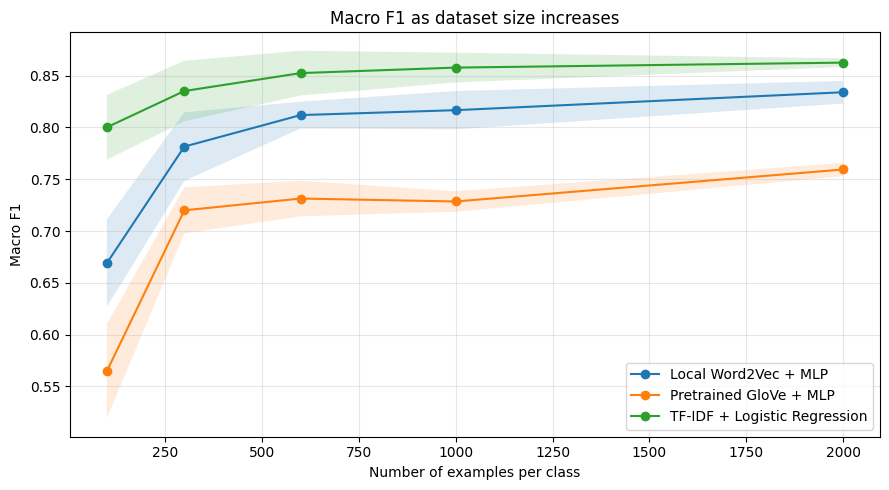

Saved: artifacts/macro_f1_vs_size.png


In [19]:
def plot_metric(summary_df: pd.DataFrame, metric_mean: str, metric_std: str, ylabel: str, out_name: str):
    plt.figure(figsize=(9, 5))

    for model_name in summary_df["model"].unique():
        subset = summary_df[summary_df["model"] == model_name].sort_values("n_per_class")
        x = subset["n_per_class"].values
        y = subset[metric_mean].values
        yerr = subset[metric_std].fillna(0).values

        plt.plot(x, y, marker="o", label=model_name)
        plt.fill_between(x, y - yerr, y + yerr, alpha=0.15)

    plt.xlabel("Number of examples per class")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} as dataset size increases")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_path = ARTIFACTS_DIR / out_name
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

plot_metric(
    summary_df,
    metric_mean="macro_f1_mean",
    metric_std="macro_f1_std",
    ylabel="Macro F1",
    out_name="macro_f1_vs_size.png"
)


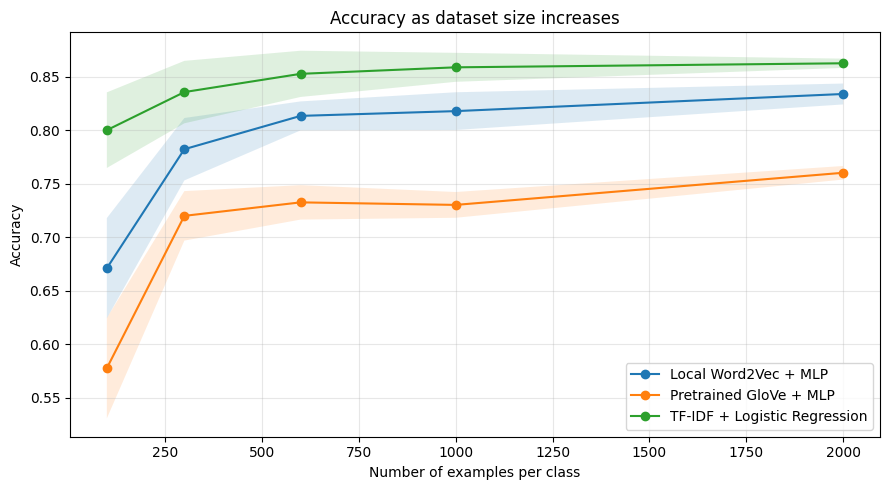

Saved: artifacts/accuracy_vs_size.png


In [20]:
plot_metric(
    summary_df,
    metric_mean="accuracy_mean",
    metric_std="accuracy_std",
    ylabel="Accuracy",
    out_name="accuracy_vs_size.png"
)


## 10. Optional: one compact chart with only the main metric

Useful for the final presentation slide.


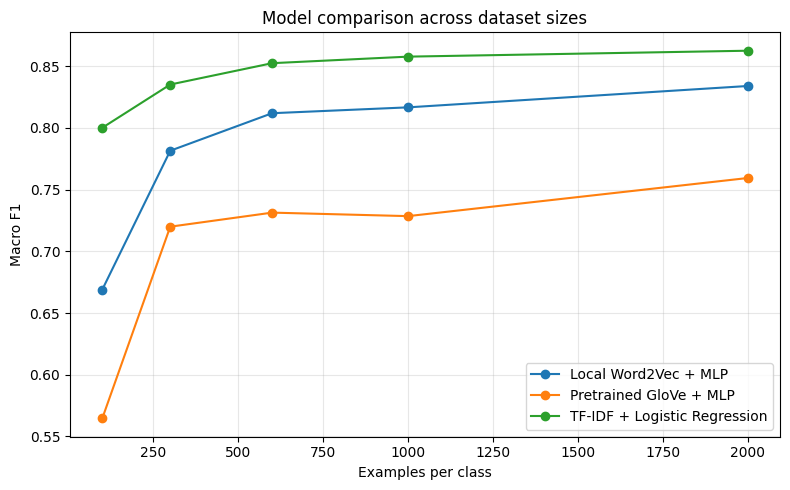

Saved: artifacts/model_comparison_compact.png


In [21]:
plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():
    subset = summary_df[summary_df["model"] == model_name].sort_values("n_per_class")
    plt.plot(subset["n_per_class"], subset["macro_f1_mean"], marker="o", label=model_name)

plt.xlabel("Examples per class")
plt.ylabel("Macro F1")
plt.title("Model comparison across dataset sizes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

compact_path = ARTIFACTS_DIR / "model_comparison_compact.png"
plt.savefig(compact_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", compact_path)
